# Phase 3 — Image Pipeline and Facial Recognition

## tl;dr

The pipeline processed **12 original member photos** into **48 rows** using the original image plus rotation, horizontal flip, and brightness augmentation. MediaPipe detected and cropped each face, and HOG produced **8,100 features per row**.

The four-member Random Forest achieved **0.979 ± 0.029 accuracy**, **0.979 ± 0.030 macro F1**, and **0.793 ± 0.067 log loss** with three-fold grouped cross-validation. A confidence threshold of **0.403** rejected both available impostor photos. The dataset is very small, so these results are a coursework demonstration rather than production biometric performance.

## Context & Methods

This notebook covers the Vision Lead deliverable: image loading, face detection, augmentation, HOG feature extraction, leakage-safe model evaluation, and known/unknown threshold testing.

### Key assumptions

- Each member folder is the identity label.
- Neutral, smiling, and surprised are different source photos of the same identity; expression is not the prediction target.
- All augmented copies remain grouped with their `source_image_id` during evaluation.
- MediaPipe short-range face detection plus HOG is used because the Windows environment could not install `dlib`/`face_recognition`.
- The two images under `image_data/impostor` are real non-member negatives used only to validate the rejection threshold.

## Data

### 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay

from scripts.image_features import member_image_paths, process_image_dataset
from scripts.train_face_model import predict_face, train_and_evaluate

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 14)

### 2. Confirm the 12 member source images

In [2]:
source_paths = member_image_paths()
inventory = pd.DataFrame({
    "member": [path.parent.name for path in source_paths],
    "expression": [path.stem.lower().replace("suprised", "surprised") for path in source_paths],
    "file": [str(path.relative_to(ROOT)) for path in source_paths],
})
display(inventory.groupby("member").size().rename("source_images").to_frame())
print("Total source images:", len(source_paths))

,source_images
member,
Gentil_Tonny_Christian_Iradukunda,3
Hassan_Adelani_Luqman,3
Mahlet_Assefa_Tilahun,3
Yvette_Uwimpaye,3


Total source images: 12


### 3. Display every member and expression

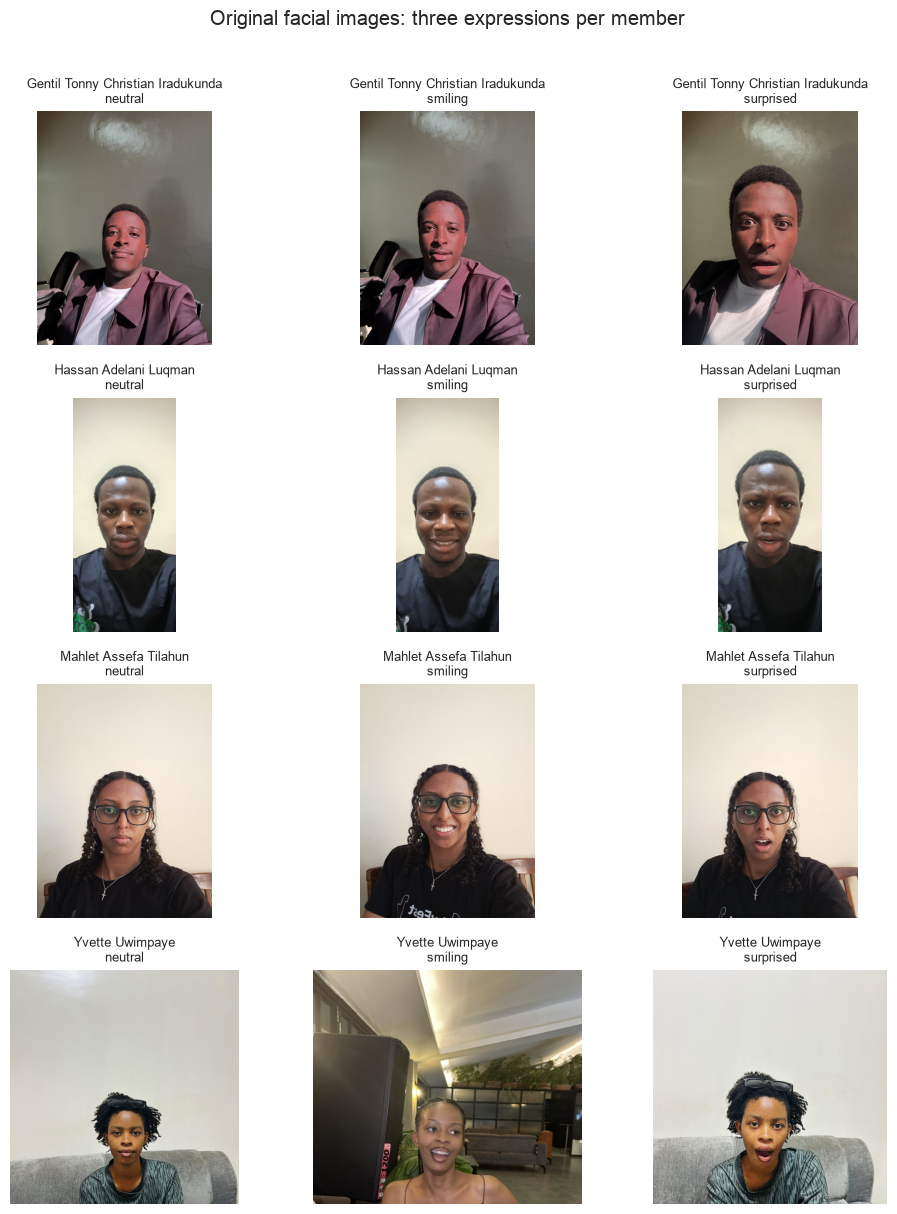

In [3]:
members = sorted(inventory["member"].unique())
expressions = ["neutral", "smiling", "surprised"]
fig, axes = plt.subplots(len(members), len(expressions), figsize=(10, 12))
for row, member in enumerate(members):
    for column, expression in enumerate(expressions):
        match = inventory[(inventory.member == member) & (inventory.expression == expression)]
        ax = axes[row, column]
        if match.empty:
            ax.text(0.5, 0.5, "Missing", ha="center", va="center")
        else:
            with Image.open(ROOT / match.iloc[0]["file"]) as image:
                ax.imshow(image)
        ax.set_title(f"{member.replace('_', ' ')}\n{expression}", fontsize=9)
        ax.axis("off")
plt.suptitle("Original facial images: three expressions per member", y=1.01)
plt.tight_layout()
plt.show()

## Results

### 4. Detect faces, augment, and extract HOG features

In [4]:
image_features = process_image_dataset()
feature_columns = [column for column in image_features if column.startswith("hog_")]
summary = image_features.groupby(["member", "variant"]).size().unstack(fill_value=0)
display(summary)
print("Feature table shape:", image_features.shape)
print("HOG features per row:", len(feature_columns))
print("Unique source images:", image_features["source_image_id"].nunique())
print("Minimum MediaPipe detection score:", round(image_features["face_detection_score"].min(), 3))

I0000 00:00:1784367916.004931 1332273 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
I0000 00:00:1784367916.125957 1332273 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784367916.130656 1332278 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


variant,brightness_115,horizontal_flip,original,rotated_10deg
member,,,,
Gentil_Tonny_Christian_Iradukunda,3,3,3,3
Hassan_Adelani_Luqman,3,3,3,3
Mahlet_Assefa_Tilahun,3,3,3,3
Yvette_Uwimpaye,3,3,3,3


Feature table shape: (48, 8108)
HOG features per row: 8100
Unique source images: 12
Minimum MediaPipe detection score: 0.891


Every member contributes three source photos. Each source produces four rows: original, 10-degree rotation, horizontal flip, and brightness increase. The `source_image_id` column keeps these related rows together during cross-validation.

### 5. Inspect one original face crop and its augmentations

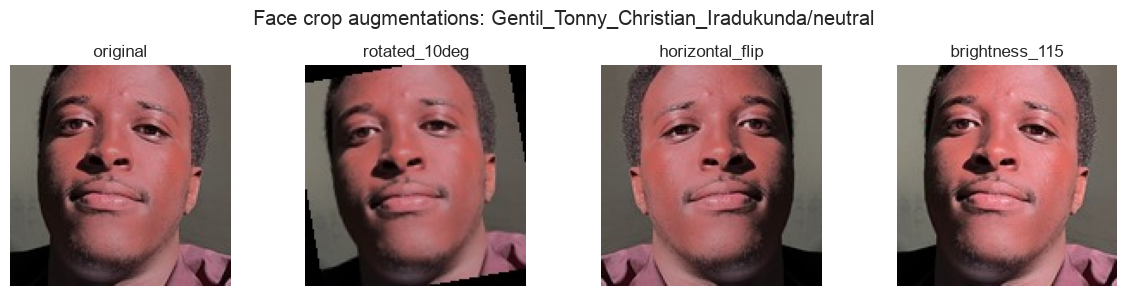

In [5]:
example_source = image_features["source_image_id"].iloc[0]
example_rows = image_features[image_features["source_image_id"] == example_source]
fig, axes = plt.subplots(1, len(example_rows), figsize=(12, 3))
for ax, (_, row) in zip(axes, example_rows.iterrows()):
    with Image.open(ROOT / row["processed_file"]) as image:
        ax.imshow(image)
    ax.set_title(row["variant"])
    ax.axis("off")
plt.suptitle(f"Face crop augmentations: {example_source}")
plt.tight_layout()
plt.show()

### 6. Train and evaluate the four-member model

In [6]:
model_bundle, face_metrics = train_and_evaluate()
fold_table = pd.DataFrame(face_metrics["folds"])
display(fold_table.round(4))

metric_summary = pd.DataFrame({
    "metric": ["Accuracy", "Macro F1", "Log loss"],
    "mean": [face_metrics["accuracy_mean"], face_metrics["f1_macro_mean"], face_metrics["log_loss_mean"]],
    "std": [face_metrics["accuracy_std"], face_metrics["f1_macro_std"], face_metrics["log_loss_std"]],
})
display(metric_summary.round(4))

I0000 00:00:1784367919.896170 1332654 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
W0000 00:00:1784367919.897071 1332659 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


,fold,accuracy,f1_macro,log_loss,train_source_images,test_source_images
0,1,1.0000,1.0000,0.8266,8,4
1,2,1.0000,1.0000,0.6992,8,4
2,3,0.9375,0.9365,0.8518,8,4


,metric,mean,std
0,Accuracy,0.9792,0.0295
1,Macro F1,0.9788,0.0299
2,Log loss,0.7925,0.0668


The split is grouped by original photo, so no rotated, flipped, or brightened copy can leak into the fold containing its source. Mean and standard deviation are reported because only 12 source images are available.

### 7. Review identity errors

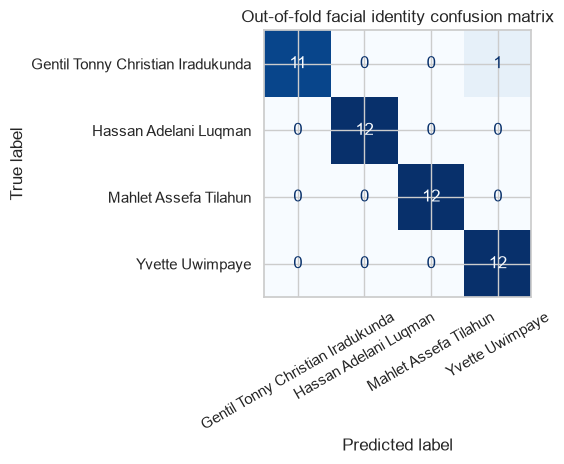

In [7]:
matrix = np.array(face_metrics["confusion_matrix"])
ConfusionMatrixDisplay(matrix, display_labels=[name.replace("_", " ") for name in face_metrics["classes"]]).plot(
    cmap="Blues", xticks_rotation=30, colorbar=False, values_format="d"
)
plt.title("Out-of-fold facial identity confusion matrix")
plt.tight_layout()
plt.show()

### 8. Validate the known/unknown confidence threshold

,file,predicted_member,member_confidence,face_detection_score
0,image_data/impostor/impostor.jpg,Gentil_Tonny_Christian_Iradukunda,0.370,0.9307
1,image_data/impostor/impostor1.jpg,Gentil_Tonny_Christian_Iradukunda,0.365,0.9367


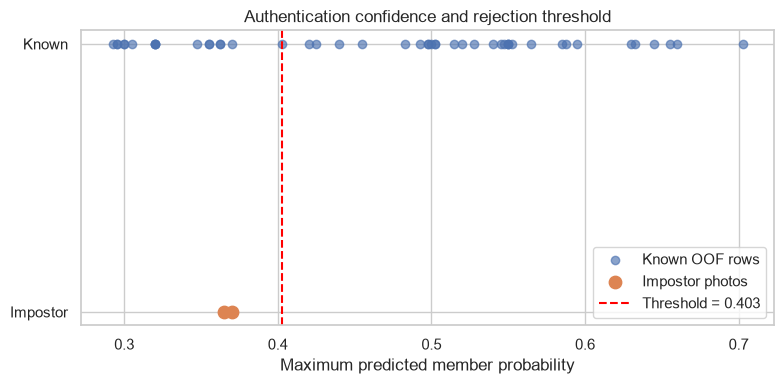

Known acceptance rate: 66.7%
Impostor rejection rate: 100.0%


In [8]:
threshold = face_metrics["confidence_threshold"]
known_confidences = np.array(face_metrics["known_oof_confidences"])
impostor_table = pd.DataFrame(face_metrics["impostor_results"])
display(impostor_table.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(known_confidences, np.ones_like(known_confidences), alpha=0.65, label="Known OOF rows")
ax.scatter(impostor_table["member_confidence"], np.zeros(len(impostor_table)), s=80, label="Impostor photos")
ax.axvline(threshold, color="red", linestyle="--", label=f"Threshold = {threshold:.3f}")
ax.set_yticks([0, 1], ["Impostor", "Known"])
ax.set_xlabel("Maximum predicted member probability")
ax.set_title("Authentication confidence and rejection threshold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Known acceptance rate:", f"{face_metrics['known_acceptance_rate']:.1%}")
print("Impostor rejection rate:", f"{face_metrics['impostor_rejection_rate']:.1%}")

The threshold rejects both available impostor photos, but it also rejects some correctly classified held-out rows whose probabilities are low. This is the security/usability trade-off created by the tiny dataset and should be stated as a limitation.

### 9. Test the final saved model

In [9]:
demo_paths = []
for member in members:
    demo_paths.append(next(path for path in source_paths if path.parent.name == member and path.stem.lower() == "neutral"))
demo_paths.extend(sorted((ROOT / "image_data" / "impostor").glob("*.jpg")))

demo_results = []
for path in demo_paths:
    result = predict_face(path)
    demo_results.append({"file": str(path.relative_to(ROOT)), **result})
display(pd.DataFrame(demo_results).round(4))

I0000 00:00:1784367920.917991 1332718 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
W0000 00:00:1784367920.918992 1332720 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


I0000 00:00:1784367921.654360 1332775 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
W0000 00:00:1784367921.655109 1332780 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


I0000 00:00:1784367922.376197 1332876 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
W0000 00:00:1784367922.377092 1332880 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


I0000 00:00:1784367923.270869 1332920 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
W0000 00:00:1784367923.271715 1332926 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


I0000 00:00:1784367924.117625 1332960 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
W0000 00:00:1784367924.118719 1332967 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


I0000 00:00:1784367924.822790 1333007 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 91.7), renderer: Apple M2 Pro
W0000 00:00:1784367924.823797 1333010 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


,file,identity,confidence,threshold,accepted,face_detection_score
0,image_data/Gentil_Tonny_Christian_Iradukunda/n...,Gentil_Tonny_Christian_Iradukunda,0.8825,0.4025,True,0.9494
1,image_data/Hassan_Adelani_Luqman/neutral.jpeg,Hassan_Adelani_Luqman,0.9100,0.4025,True,0.9414
2,image_data/Mahlet_Assefa_Tilahun/neutral.jpg,Mahlet_Assefa_Tilahun,0.9300,0.4025,True,0.9590
3,image_data/Yvette_Uwimpaye/neutral.jpg,Yvette_Uwimpaye,0.9125,0.4025,True,0.9613
4,image_data/impostor/impostor.jpg,Gentil_Tonny_Christian_Iradukunda,0.3700,0.4025,False,0.9307
5,image_data/impostor/impostor1.jpg,Gentil_Tonny_Christian_Iradukunda,0.3650,0.4025,False,0.9367


## Takeaways

- All four members have neutral, smiling, and surprised source images.
- MediaPipe detected a face in all 12 member images and both impostor images.
- The feature CSV contains original and augmented rows with leakage-safe `source_image_id` values.
- Grouped cross-validation evaluates identity recognition without placing copies of one photo on both sides of a fold.
- The saved model recognizes the four demonstrated member images and rejects both impostor examples at the selected threshold.
- With only three source photos per person and two impostors, results must be presented as a coursework simulation, not a production biometric system.